<a href="https://www.kaggle.com/code/lalit7881/multi-brand-campaign-insights-v3?scriptVersionId=301346392" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sshriya08/multi-brand-marketing-campaign-performance-dataset/nykaa_campaign_data.csv
/kaggle/input/datasets/sshriya08/multi-brand-marketing-campaign-performance-dataset/purplle_campaign_data.csv
/kaggle/input/datasets/sshriya08/multi-brand-marketing-campaign-performance-dataset/tira_campaign_data.csv


## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sshriya08/multi-brand-marketing-campaign-performance-dataset/tira_campaign_data.csv")

In [3]:
df.head()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,TI-CMP-1000,SEO,Working Women,11,Instagram,64004,2906,1639,952,222768,129.72,0.80,Tamil,8.59,Premium Shoppers,30-10-2024
1,TI-CMP-1001,Social Media,Tier 2 City Customers,24,YouTube,71795,2051,552,256,199168,316.36,1.46,Tamil,3.98,College Students,11-09-2024
2,TI-CMP-1002,Paid Ads,Working Women,28,Instagram,79158,3546,1928,1314,433620,91.25,2.62,English,8.58,Tier 2 City Customers,28-08-2024
3,TI-CMP-1003,Email,Youth,8,Google,31523,3721,2088,736,571872,161.13,3.82,Bengali,20.76,Youth,27-07-2024
4,TI-CMP-1004,Paid Ads,Premium Shoppers,15,"Facebook, Email, WhatsApp",61441,7277,3615,2602,1477936,82.07,5.92,Tamil,21.96,College Students,19-12-2024


In [4]:
df.tail()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
55550,TI-CMP-56550,Influencer,Tier 2 City Customers,11,"Instagram, YouTube, Email",60137,3799,1539,1099,454986,213.21,0.94,Bengali,10.70,Youth,12-11-2024
55551,TI-CMP-56551,SEO,Working Women,20,"Google, Instagram",54886,1578,634,343,136514,436.24,-0.09,English,4.66,Working Women,25-08-2024
55552,TI-CMP-56552,Email,Tier 2 City Customers,13,"Facebook, Instagram",97954,11480,4567,2144,445952,78.77,1.64,Bengali,18.57,Premium Shoppers,15-04-2025
55553,TI-CMP-56553,Influencer,Premium Shoppers,22,"Google, Email",11669,458,122,44,26884,2578.39,-0.76,English,5.35,Working Women,21-07-2024
55554,TI-CMP-56554,Paid Ads,Working Women,9,Instagram,50497,1604,542,363,281688,151.44,4.12,English,4.97,Premium Shoppers,02-05-2025


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       55555 non-null  object 
 1   Campaign_Type     55555 non-null  object 
 2   Target_Audience   55555 non-null  object 
 3   Duration          55555 non-null  int64  
 4   Channel_Used      55555 non-null  object 
 5   Impressions       55555 non-null  int64  
 6   Clicks            55555 non-null  int64  
 7   Leads             55555 non-null  int64  
 8   Conversions       55555 non-null  int64  
 9   Revenue           55555 non-null  int64  
 10  Acquisition_Cost  55555 non-null  float64
 11  ROI               55555 non-null  float64
 12  Language          55555 non-null  object 
 13  Engagement_Score  55555 non-null  float64
 14  Customer_Segment  55555 non-null  object 
 15  Date              55555 non-null  object 
dtypes: float64(3), int64(6), object(7)
memor

In [6]:
df.describe()

,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score
count,55555.000000,55555.000000,55555.000000,55555.000000,55555.000000,5.555500e+04,55555.000000,55555.000000,55555.000000
mean,17.532733,55029.057619,4676.494501,1866.821492,1026.116623,5.121688e+05,374.277331,2.674971,13.758096
std,7.499725,26013.553717,3171.969630,1422.167419,853.726296,4.846412e+05,529.366070,4.470778,6.304495
min,5.000000,10001.000000,208.000000,50.000000,17.000000,3.895000e+03,8.180000,-0.990000,2.580000
25%,11.000000,32457.500000,2106.000000,779.000000,402.500000,1.783625e+05,107.420000,0.050000,8.420000
50%,18.000000,54999.000000,3903.000000,1475.000000,775.000000,3.594540e+05,208.160000,1.240000,13.590000
75%,24.000000,77526.000000,6671.000000,2598.000000,1394.000000,6.814710e+05,424.845000,3.550000,18.730000
max,30.000000,99999.000000,14944.000000,8761.000000,6415.000000,4.517478e+06,15038.000000,79.300000,30.520000


In [7]:
df.isnull().sum()

Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Campaign_ID          object
Campaign_Type        object
Target_Audience      object
Duration              int64
Channel_Used         object
Impressions           int64
Clicks                int64
Leads                 int64
Conversions           int64
Revenue               int64
Acquisition_Cost    float64
ROI                 float64
Language             object
Engagement_Score    float64
Customer_Segment     object
Date                 object
dtype: object

In [10]:
df.shape

(55555, 16)

In [11]:
df.columns

Index(['Campaign_ID', 'Campaign_Type', 'Target_Audience', 'Duration',
       'Channel_Used', 'Impressions', 'Clicks', 'Leads', 'Conversions',
       'Revenue', 'Acquisition_Cost', 'ROI', 'Language', 'Engagement_Score',
       'Customer_Segment', 'Date'],
      dtype='object')

In [12]:
df.nunique()

Campaign_ID         55555
Campaign_Type           5
Target_Audience         5
Duration               26
Channel_Used          156
Impressions         41497
Clicks              12099
Leads                6291
Conversions          4154
Revenue             49403
Acquisition_Cost    37328
ROI                  2480
Language                4
Engagement_Score     2666
Customer_Segment        5
Date                  359
dtype: int64

## EDA

In [13]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9,5)

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [14]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9,5)

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

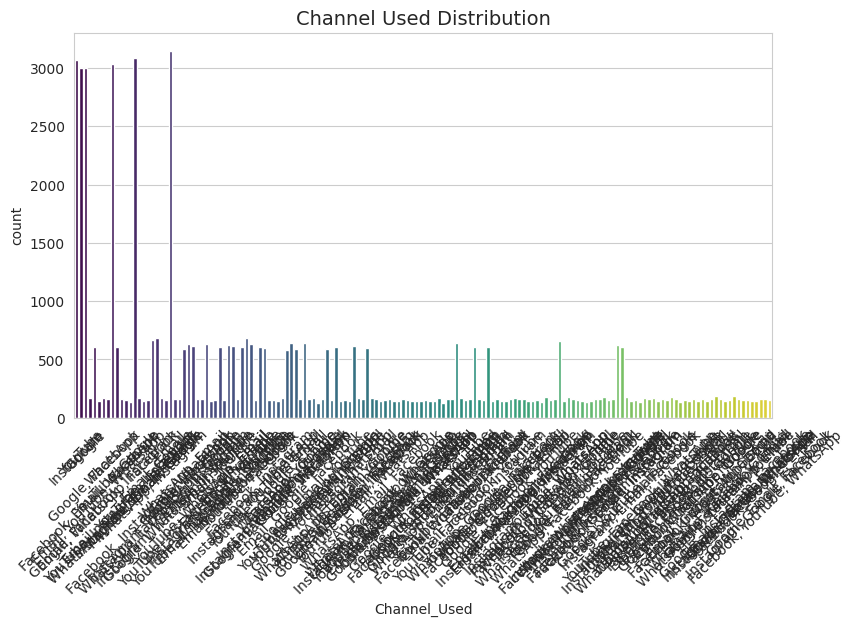

In [15]:
plt.figure()
sns.countplot(
    x="Channel_Used",
    data=df,
    palette="viridis"
)
plt.title("Channel Used Distribution", fontsize=14)
plt.xticks(rotation=45)
plt.show()

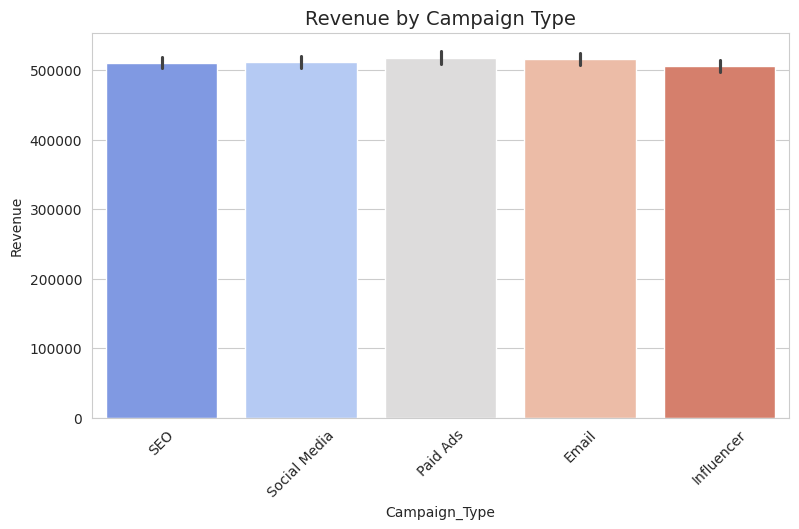

In [16]:
plt.figure()
sns.barplot(
    x="Campaign_Type",
    y="Revenue",
    data=df,
    palette="coolwarm"
)
plt.title("Revenue by Campaign Type", fontsize=14)
plt.xticks(rotation=45)
plt.show()

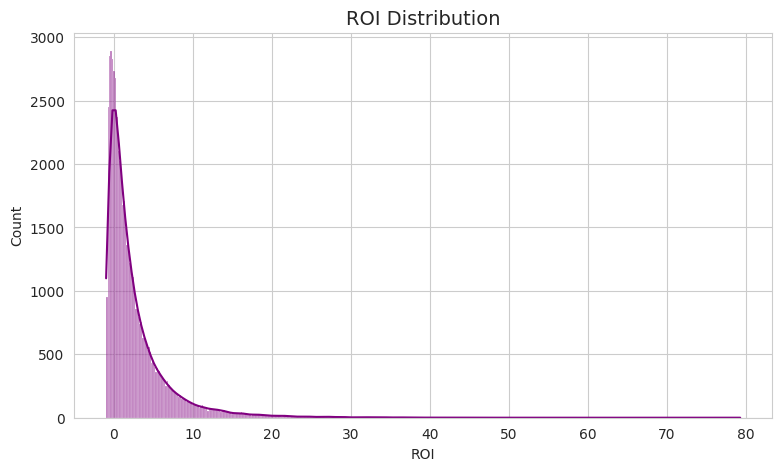

In [17]:
plt.figure()
sns.histplot(
    df["ROI"],
    kde=True,
    color="purple"
)
plt.title("ROI Distribution", fontsize=14)
plt.show()

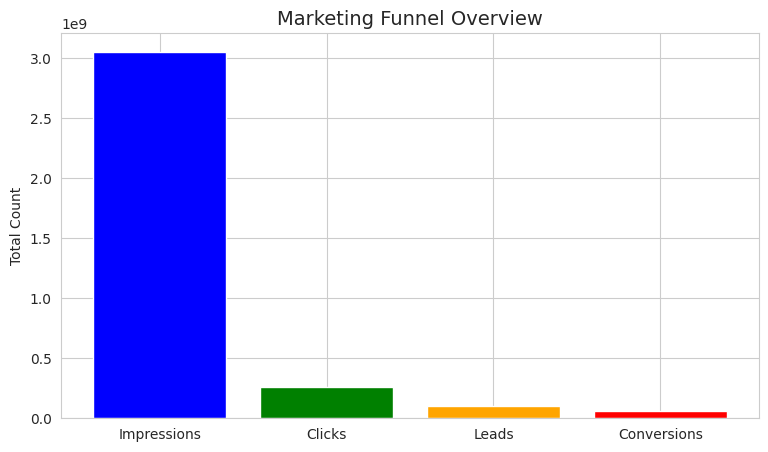

In [18]:
funnel_values = [
    df["Impressions"].sum(),
    df["Clicks"].sum(),
    df["Leads"].sum(),
    df["Conversions"].sum()
]

stages = ["Impressions", "Clicks", "Leads", "Conversions"]

plt.figure()
plt.bar(
    stages,
    funnel_values,
    color=["blue", "green", "orange", "red"]
)
plt.title("Marketing Funnel Overview", fontsize=14)
plt.ylabel("Total Count")
plt.show()

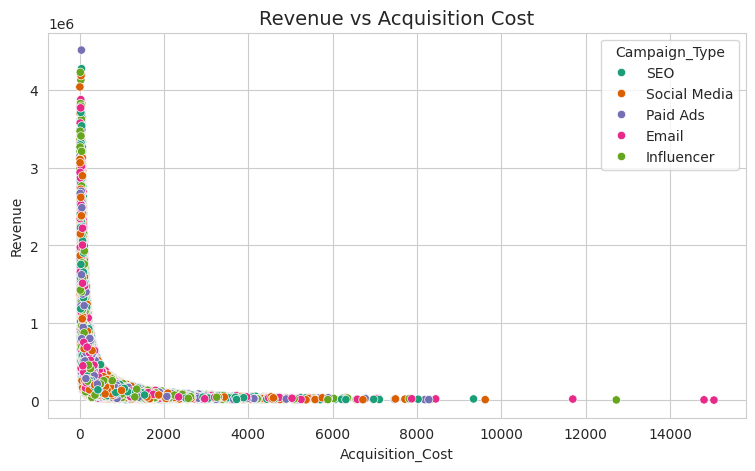

In [19]:
plt.figure()
sns.scatterplot(
    x="Acquisition_Cost",
    y="Revenue",
    hue="Campaign_Type",
    palette="Dark2",
    data=df
)
plt.title("Revenue vs Acquisition Cost", fontsize=14)
plt.show()

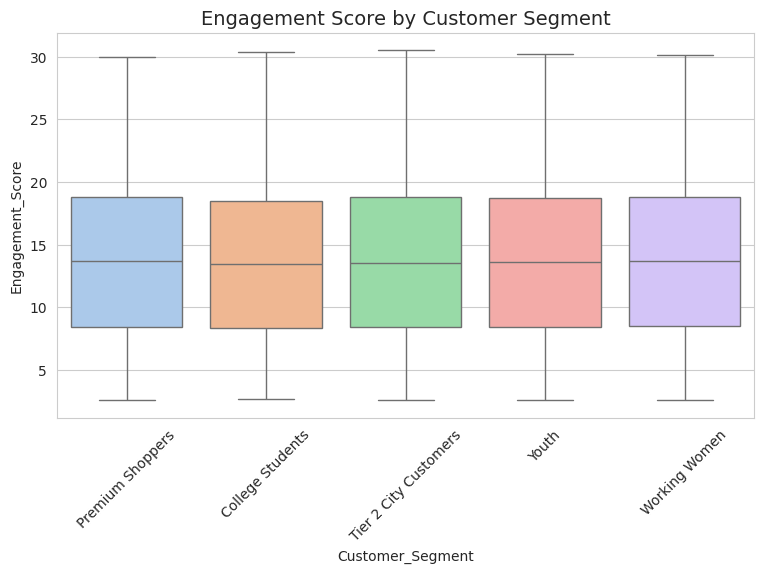

In [20]:
plt.figure()
sns.boxplot(
    x="Customer_Segment",
    y="Engagement_Score",
    data=df,
    palette="pastel"
)
plt.title("Engagement Score by Customer Segment", fontsize=14)
plt.xticks(rotation=45)
plt.show()

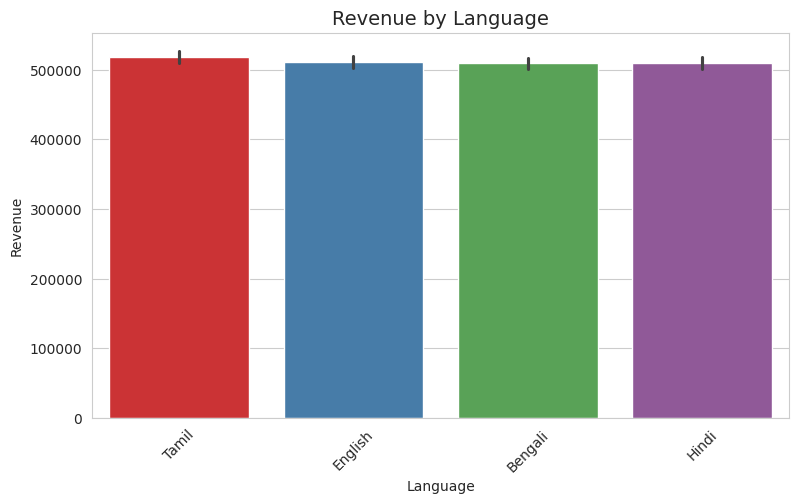

In [21]:
plt.figure()
sns.barplot(
    x="Language",
    y="Revenue",
    data=df,
    palette="Set1"
)
plt.title("Revenue by Language", fontsize=14)
plt.xticks(rotation=45)
plt.show()

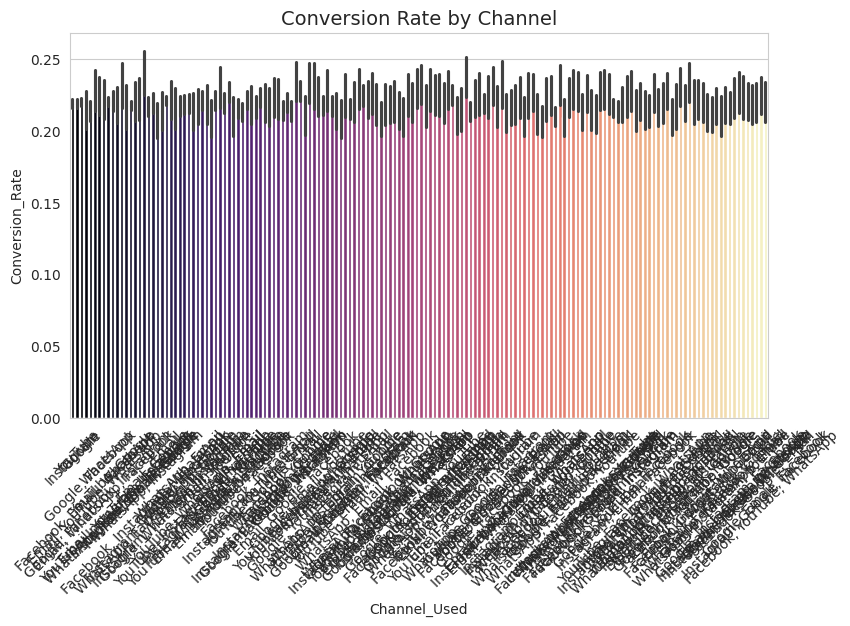

In [22]:
df["Conversion_Rate"] = df["Conversions"] / df["Clicks"]

plt.figure()
sns.barplot(
    x="Channel_Used",
    y="Conversion_Rate",
    data=df,
    palette="magma"
)
plt.title("Conversion Rate by Channel", fontsize=14)
plt.xticks(rotation=45)
plt.show()

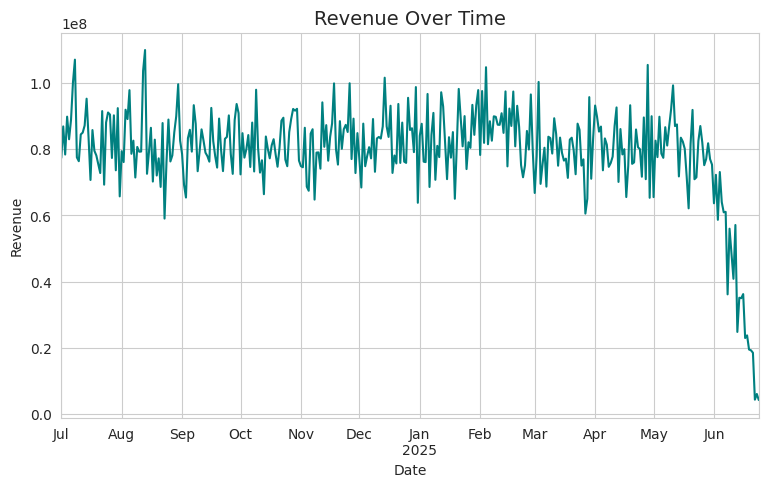

In [23]:
revenue_trend = df.groupby("Date")["Revenue"].sum()

plt.figure()
revenue_trend.plot(color="teal")
plt.title("Revenue Over Time", fontsize=14)
plt.ylabel("Revenue")
plt.show()

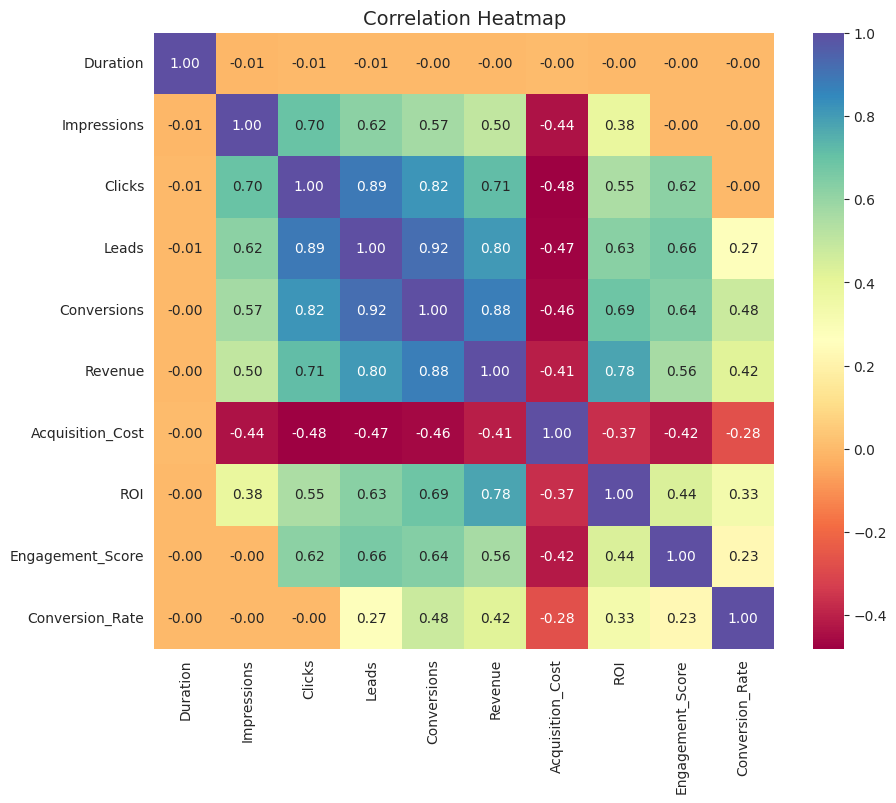

In [24]:
numeric_cols = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="Spectral",
    fmt=".2f"
)
plt.title("Correlation Heatmap", fontsize=14)
plt.show()

## Feature engineering

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [26]:
# Drop ID column (not useful for ML)
df = df.drop(columns=["Campaign_ID"], errors="ignore")

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Extract useful features from Date
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

df = df.drop(columns=["Date"])

# Fill missing numeric values
num_cols = df.select_dtypes(include=["int64","float64"]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [27]:
roi_median = df["ROI"].median()
df["High_ROI"] = np.where(df["ROI"] > roi_median, 1, 0)

# 🚨 Remove leakage columns
df = df.drop(columns=["ROI", "Revenue", "Conversions"], errors="ignore")

X = df.drop("High_ROI", axis=1)
y = df["High_ROI"]

print("Class Distribution:")
print(y.value_counts())

Class Distribution:
High_ROI
0    27863
1    27692
Name: count, dtype: int64


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)



In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True)
}

In [31]:
results = {}

for name, model in models.items():
    
    pipe = Pipeline(steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc
    
    print("\n==============================")
    print(name)
    print("Accuracy: {:.2f}%".format(acc))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))



Logistic Regression
Accuracy: 87.42%

Confusion Matrix:
[[4689  884]
 [ 514 5024]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      5573
           1       0.85      0.91      0.88      5538

    accuracy                           0.87     11111
   macro avg       0.88      0.87      0.87     11111
weighted avg       0.88      0.87      0.87     11111


Random Forest
Accuracy: 87.22%

Confusion Matrix:
[[4662  911]
 [ 509 5029]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      5573
           1       0.85      0.91      0.88      5538

    accuracy                           0.87     11111
   macro avg       0.87      0.87      0.87     11111
weighted avg       0.87      0.87      0.87     11111


Gradient Boosting
Accuracy: 87.31%

Confusion Matrix:
[[4593  980]
 [ 430 5108]]

Classification Report:
              precision    rec

In [32]:
trained_models = {}

for name, model in models.items():
    
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

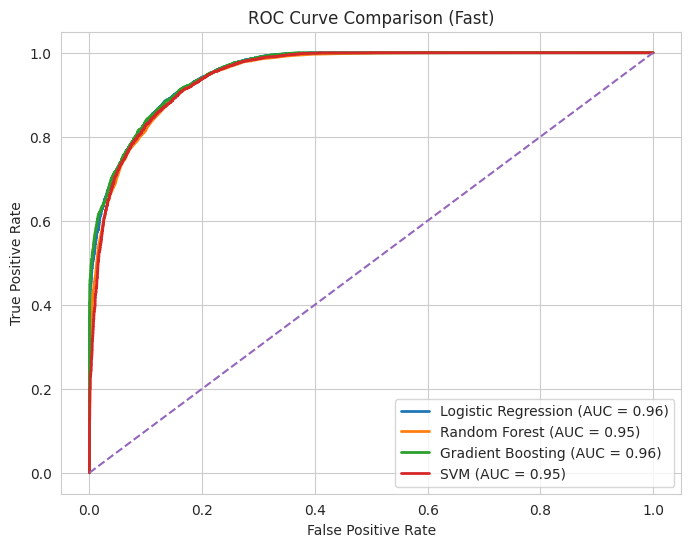

In [33]:
plt.figure(figsize=(8,6))

for name, pipe in trained_models.items():
    
    model = pipe.named_steps["model"]
    
    if hasattr(model, "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        y_prob = pipe.decision_function(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Fast)")
plt.legend()
plt.grid(True)
plt.show()

## Thank you..pls upvote!!!!!!!!!